# 03 - Study Habits & Challenging Subjects

Analyze study patterns, study methods, subjects, and extracurricular activities.

In [1]:
import sys
sys.path.insert(0, '../scripts')
from helpers import *
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load and clean data
df = load_survey_data()
df = clean_survey_data(df)
print(f"Loaded {len(df)} survey responses")

Loaded 34 survey responses


In [3]:
# Study habits summary
get_study_habits_summary(df)

STUDY HABITS SUMMARY
Study Hours Distribution:
average_hours_spent_studying_per_day
Less than 1 hour     12
1–2 hours             9
2–4 hours             9
More than 4 hours     4
Name: count, dtype: int64

Preferred Study Methods:
preferred_study_method
Self-study                                                  15
Self-study;Online tutorials                                  6
Self-study;Coaching classes                                  4
Coaching classes                                             3
Group study                                                  2
Self-study;Online tutorials;Coaching classes                 1
Self-study;Group study;Online tutorials                      1
Online tutorials                                             1
Self-study;Group study;Online tutorials;Coaching classes     1
Name: count, dtype: int64


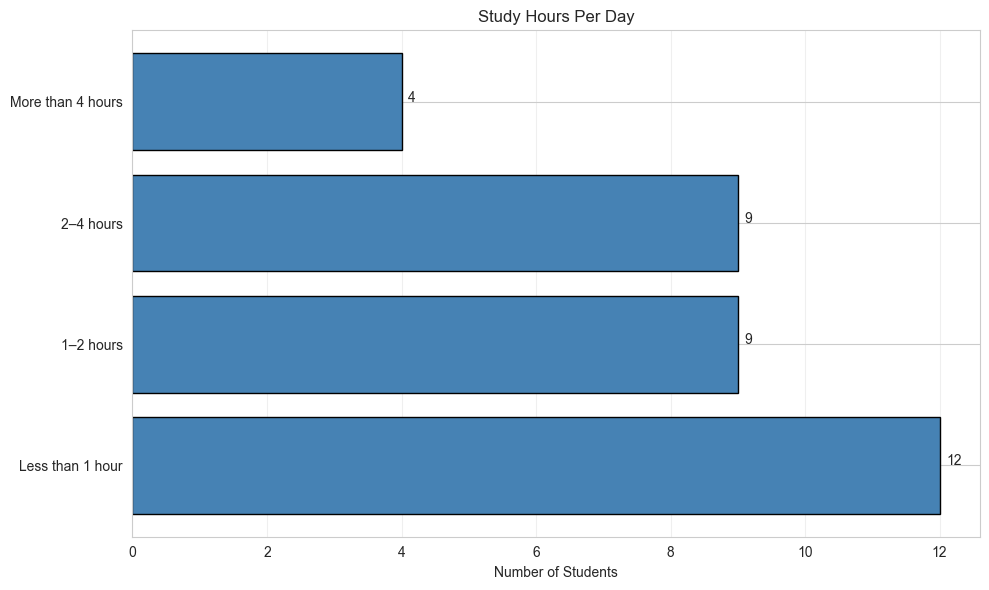

In [4]:
# Study hours distribution
fig, ax = plt.subplots(figsize=(10, 6))
hours_counts = df['average_hours_spent_studying_per_day'].value_counts()
# Order by hours
order = ['Less than 1 hour', '1–2 hours', '2–4 hours', 'More than 4 hours']
hours_ordered = [hours_counts.get(h, 0) for h in order]
ax.barh(order, hours_ordered, color='steelblue', edgecolor='black')
ax.set_xlabel('Number of Students')
ax.set_title('Study Hours Per Day')
ax.grid(alpha=0.3, axis='x')
for i, v in enumerate(hours_ordered):
    ax.text(v + 0.1, i, str(v))
plt.tight_layout()
plt.show()

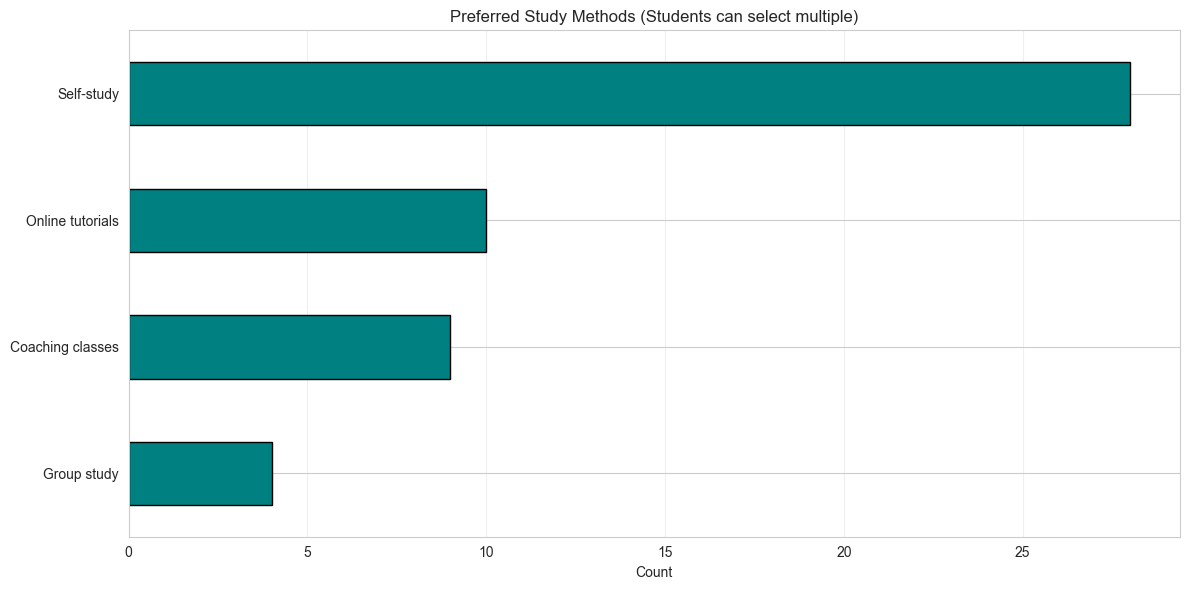

In [5]:
# Extract all study methods (multi-select)
study_methods = {}
for methods_str in df['preferred_study_method'].dropna():
    if isinstance(methods_str, str):
        methods = [m.strip() for m in methods_str.split(';')]
        for m in methods:
            study_methods[m] = study_methods.get(m, 0) + 1

# Plot study methods
fig, ax = plt.subplots(figsize=(12, 6))
methods_df = pd.Series(study_methods).sort_values()
methods_df.plot(kind='barh', color='teal', edgecolor='black', ax=ax)
ax.set_xlabel('Count')
ax.set_title('Preferred Study Methods (Students can select multiple)')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

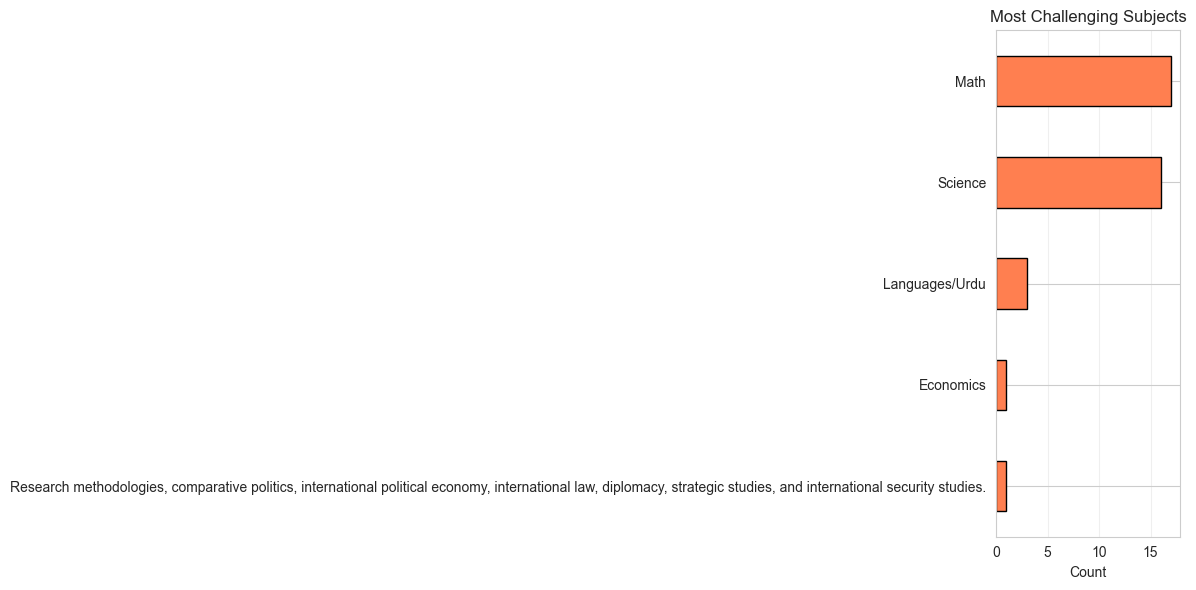

In [6]:
# Extract challenging subjects (multi-select)
challenging_subjects = {}
for subjects_str in df['subject(s)_you_find_most_challenging'].dropna():
    if isinstance(subjects_str, str):
        subjects = [s.strip() for s in subjects_str.split(';')]
        for s in subjects:
            if s and len(s) > 2:  # Filter out empty/short strings
                # Normalize to main subjects
                if 'math' in s.lower():
                    challenging_subjects['Math'] = challenging_subjects.get('Math', 0) + 1
                elif 'science' in s.lower() or 'physics' in s.lower() or 'chem' in s.lower() or 'bio' in s.lower():
                    challenging_subjects['Science'] = challenging_subjects.get('Science', 0) + 1
                elif 'urdu' in s.lower() or 'islamiat' in s.lower() or 'pakistan' in s.lower():
                    challenging_subjects['Languages/Urdu'] = challenging_subjects.get('Languages/Urdu', 0) + 1
                else:
                    challenging_subjects[s] = challenging_subjects.get(s, 0) + 1

# Plot challenging subjects
fig, ax = plt.subplots(figsize=(12, 6))
subjects_df = pd.Series(challenging_subjects).sort_values()
subjects_df.plot(kind='barh', color='coral', edgecolor='black', ax=ax)
ax.set_xlabel('Count')
ax.set_title('Most Challenging Subjects')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

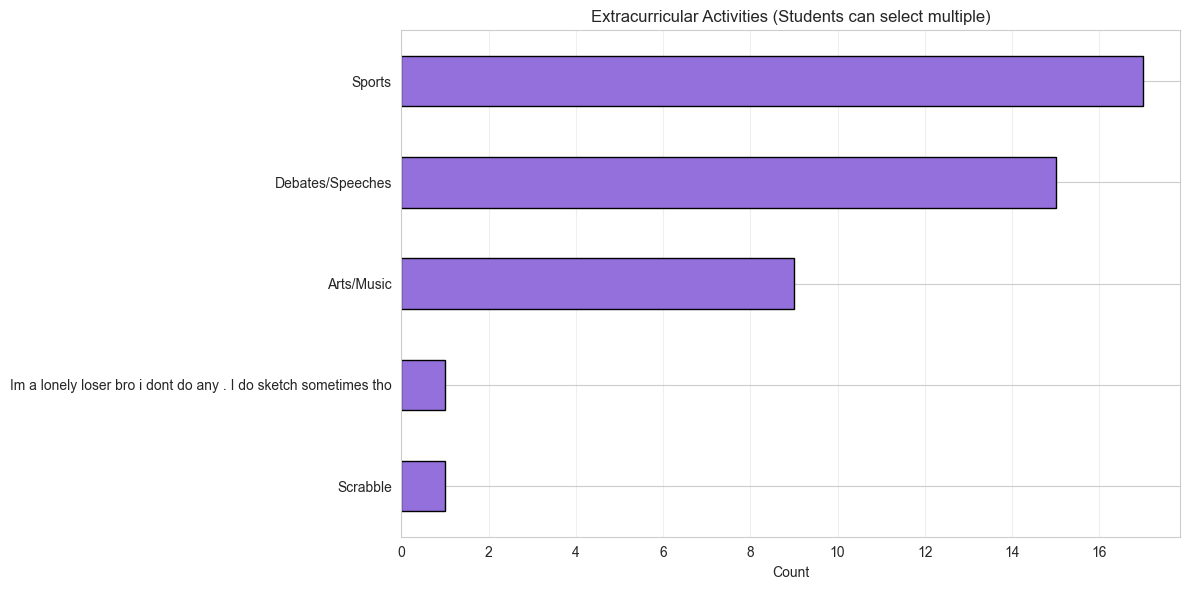

In [7]:
# Extract extracurricular activities
activities = {}
for activities_str in df['extra-curricular_activities_you_participate_in'].dropna():
    if isinstance(activities_str, str) and activities_str.strip():
        acts = [a.strip() for a in activities_str.split(';')]
        for a in acts:
            if a:
                activities[a] = activities.get(a, 0) + 1

# Plot extracurricular activities
fig, ax = plt.subplots(figsize=(12, 6))
activities_df = pd.Series(activities).sort_values()
activities_df.plot(kind='barh', color='mediumpurple', edgecolor='black', ax=ax)
ax.set_xlabel('Count')
ax.set_title('Extracurricular Activities (Students can select multiple)')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()